Epoch 0, Loss: 0.6931
Epoch 50, Loss: 0.6532
Epoch 100, Loss: 0.6231
Epoch 150, Loss: 0.6001
Epoch 200, Loss: 0.5824
Epoch 250, Loss: 0.5684
Epoch 300, Loss: 0.5574
Epoch 350, Loss: 0.5485
Epoch 400, Loss: 0.5413
Epoch 450, Loss: 0.5354

Final Accuracy: 0.7682291666666666


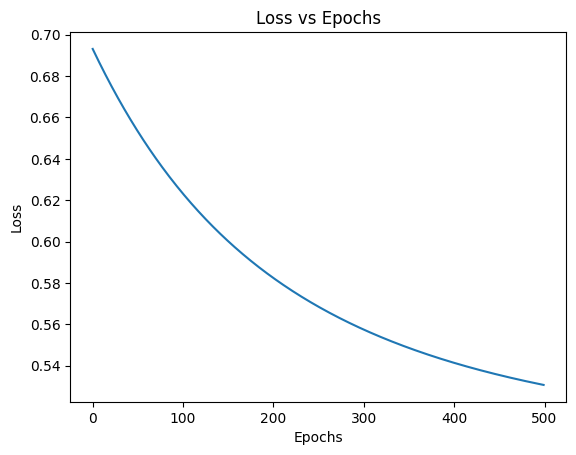

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Load Data
# =========================
df = pd.read_csv("./Data/diabetes.csv")

X = df[["Glucose","BMI"]].values
y = df["Outcome"].values

# =========================
# 2. Feature Scaling
# =========================
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X = (X - X_mean) / X_std

# =========================
# 3. Sigmoid (stable)
# =========================
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1/(1 + np.exp(-z))

# =========================
# 4. Initialize Parameters
# =========================
w = np.zeros(2)
c = 0

lr = 0.01
epochs = 500
n = len(y)

# =========================
# 5. Training Loop
# =========================
losses = []

for i in range(epochs):
    
    # Forward pass
    z = X @ w + c
    y_pred = sigmoid(z)
    
    # Gradients
    dw = (1/n) * (X.T @ (y_pred - y))
    dc = (1/n) * np.sum(y_pred - y)
    
    # Update
    w = w - lr*dw
    c = c - lr*dc
    
    # Loss
    loss = (-1/n) * np.sum(
        y*np.log(y_pred + 1e-9) +
        (1-y)*np.log(1-y_pred + 1e-9)
    )
    losses.append(loss)
    
    if i % 50 == 0:
        print(f"Epoch {i}, Loss: {loss:.4f}")

# =========================
# 6. Evaluation
# =========================
z_final = X @ w + c
probabilities = sigmoid(z_final)

y_pred_class = (probabilities >= 0.5).astype(int)

accuracy = np.mean(y_pred_class == y)

print("\nFinal Accuracy:", accuracy)

# =========================
# 7. Loss Curve
# =========================
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
